# Task 1 - EDA on Filtered Complaints
Analysis of the cleaned, filtered CFPB dataset for CrediTrust Financial

In [1]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
%matplotlib inline
sns.set_style('whitegrid')
os.makedirs('../data/processed', exist_ok=True)
print('Libraries loaded!')

Libraries loaded!


## Full Dataset Summary
These numbers come from running `src/preprocessing.py` on the complete 9.6M-row CFPB dataset.

In [2]:
with open('../data/processed/eda_summary.json') as f:
    summary = json.load(f)
print(f"Full CFPB dataset: {summary['full_dataset_rows']:,} complaints")
print(f"With narrative text: {summary['with_narrative']:,}")
print(f"Without narrative text: {summary['without_narrative']:,}")
print(f"Target products (before narrative filter): {summary['target_product_rows_before_narrative_filter']:,}")
print(f"Final filtered dataset: {summary['final_filtered_rows']:,}")

Full CFPB dataset: 9,609,797 complaints
With narrative text: 2,980,756
Without narrative text: 6,629,041
Target products (before narrative filter): 1,039,587
Final filtered dataset: 478,818


## Narrative Presence - Full Dataset

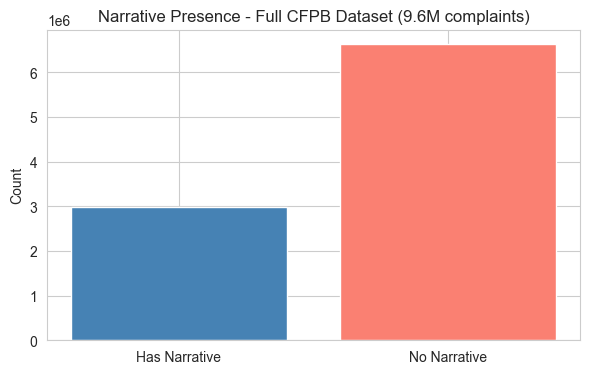

In [3]:
plt.figure(figsize=(6,4))
plt.bar(['Has Narrative','No Narrative'],
        [summary['with_narrative'], summary['without_narrative']],
        color=['steelblue','salmon'])
plt.title('Narrative Presence - Full CFPB Dataset (9.6M complaints)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/processed/narrative_presence.png')
plt.show()

## Load Filtered Dataset (4 Target Products Only)

In [4]:
df = pl.read_csv(
    '../data/filtered_complaints.csv',
    columns=['product_category', 'cleaned_narrative']
)
print(f'Loaded: {df.shape}')
df.head()

Loaded: (478818, 2)


product_category,cleaned_narrative
str,str
"""Credit card""","""a card was opened under my nam…"
"""Savings account""","""i made the mistake of using my…"
"""Credit card""","""dear cfpb i have a secured cre…"
"""Credit card""","""i have a citi rewards cards th…"
"""Credit card""","""b i am writing to dispute the …"


## Product Distribution - Final Dataset

shape: (4, 2)
┌──────────────────┬────────┐
│ product_category ┆ count  │
│ ---              ┆ ---    │
│ str              ┆ u32    │
╞══════════════════╪════════╡
│ Credit card      ┆ 189334 │
│ Savings account  ┆ 155204 │
│ Money transfer   ┆ 98685  │
│ Personal loan    ┆ 35595  │
└──────────────────┴────────┘


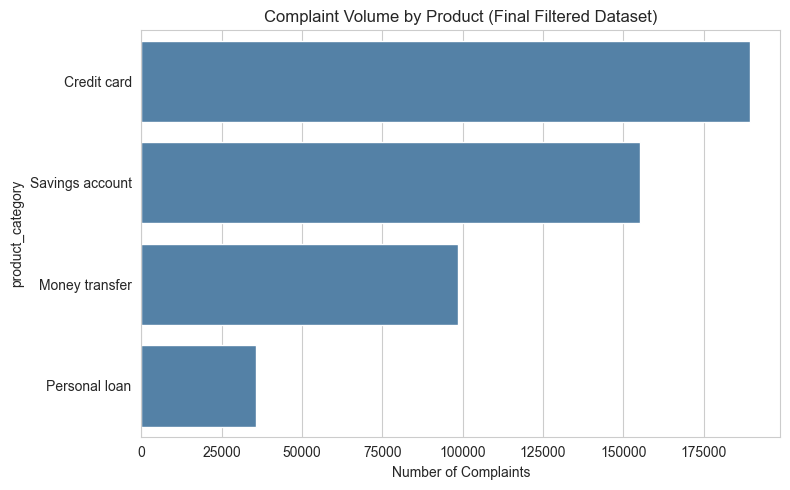

In [5]:
product_counts = df['product_category'].value_counts().sort('count', descending=True)
print(product_counts)
pc_pd = product_counts.to_pandas()
plt.figure(figsize=(8,5))
sns.barplot(data=pc_pd, x='count', y='product_category', color='steelblue')
plt.title('Complaint Volume by Product (Final Filtered Dataset)')
plt.xlabel('Number of Complaints')
plt.tight_layout()
plt.savefig('../data/processed/product_distribution_final.png')
plt.show()

## Narrative Word Count Analysis

In [6]:
df = df.with_columns(
    pl.col('cleaned_narrative').str.split(' ').list.len().alias('word_count')
)
plot_df = df.select(['product_category', 'word_count']).to_pandas()
print(plot_df['word_count'].describe())

count    478818.000000
mean        196.487787
std         212.513975
min           1.000000
25%          79.000000
50%         132.000000
75%         245.000000
max        6239.000000
Name: word_count, dtype: float64


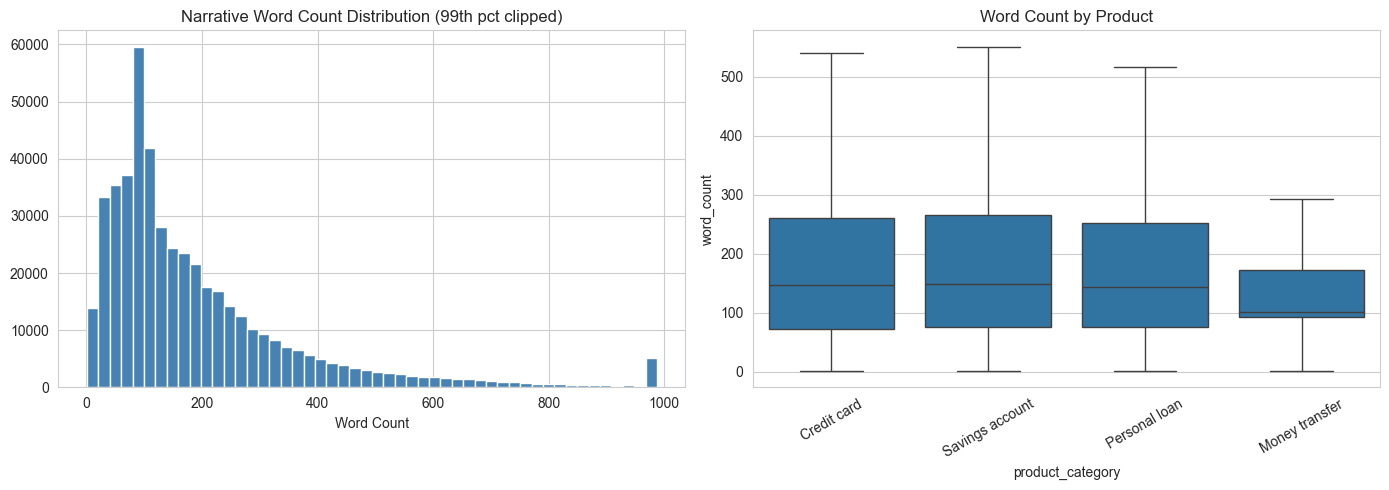

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
plot_df['word_count'].clip(upper=plot_df['word_count'].quantile(0.99)).hist(
    bins=50, ax=axes[0], color='steelblue'
)
axes[0].set_title('Narrative Word Count Distribution (99th pct clipped)')
axes[0].set_xlabel('Word Count')
sns.boxplot(data=plot_df, x='product_category', y='word_count',
            ax=axes[1], showfliers=False)
axes[1].set_title('Word Count by Product')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../data/processed/word_count_analysis.png')
plt.show()

## Key EDA Findings

- The full CFPB dataset contains **9.6 million** complaints across all financial product categories, but only **31%** include a written narrative.
- Filtering to our 4 target products (Credit Card, Personal Loan, Savings Account, Money Transfer) leaves **1,039,587** complaints.
- Of those, **54%** had no narrative text and were dropped, leaving a final analysis-ready dataset of **478,818** complaints.
- Credit Card and Savings Account complaints dominate the dataset; Personal Loan is the smallest category by volume.
- Narrative lengths vary substantially across products, which matters for our chunking strategy in Task 2 (longer narratives will produce more chunks per complaint).
